In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor
import shap

C:\Users\parth\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv(os.path.join("..", "DATA", "data", "final_dataset.csv"))

df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time")

df.head()

,time,load,wind,solar,price
0,2025-01-01 00:00:00,47741.75,35377.75,9.50,2.16
1,2025-01-01 01:00:00,46867.25,35915.50,9.50,1.60
2,2025-01-01 02:00:00,45797.50,36381.00,9.00,0.00
3,2025-01-01 03:00:00,44623.50,34560.50,9.25,-0.01
4,2025-01-01 04:00:00,43626.00,34441.50,9.00,-0.01


In [3]:
df["price_lag_1"] = df["price"].shift(1)
df["price_lag_24"] = df["price"].shift(24)
df["price_rolling_24"] = df["price"].rolling(24).mean()

df["hour"] = df["time"].dt.hour
df["day_of_week"] = df["time"].dt.dayofweek

df = df.dropna()

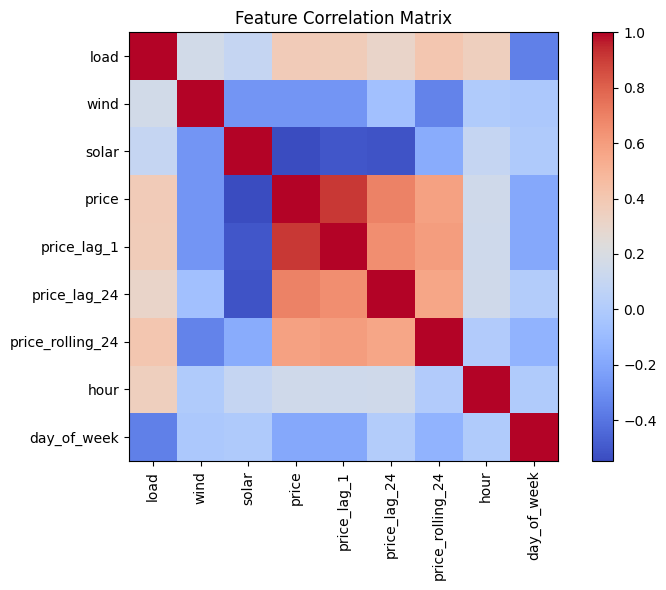

In [4]:
plt.figure(figsize=(8,6))
corr = df.corr(numeric_only=True)

plt.imshow(corr, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

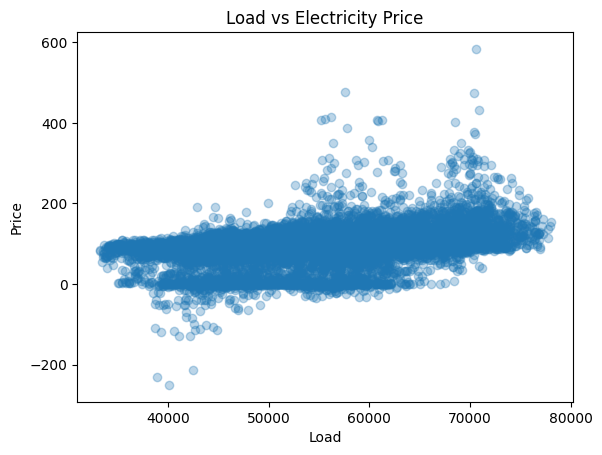

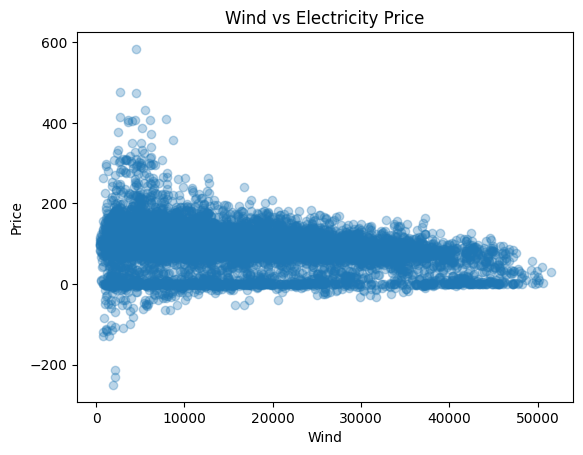

In [5]:
# Load vs Price
plt.figure()
plt.scatter(df["load"], df["price"], alpha=0.3)
plt.xlabel("Load")
plt.ylabel("Price")
plt.title("Load vs Electricity Price")
plt.show()

# Wind vs Price
plt.figure()
plt.scatter(df["wind"], df["price"], alpha=0.3)
plt.xlabel("Wind")
plt.ylabel("Price")
plt.title("Wind vs Electricity Price")
plt.show()

In [6]:
X = df[[
    "load", "wind", "solar",
    "price_lag_1", "price_lag_24",
    "price_rolling_24",
    "hour", "day_of_week"
]]

y = df["price"]

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Linear MAE:", mean_absolute_error(y_test, predictions))
print("Linear R2:", r2_score(y_test, predictions))

Linear MAE: 9.302549500183474
Linear R2: 0.8587872880691467


In [8]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

print("Random Forest MAE:", mean_absolute_error(y_test, rf_predictions))
print("Random Forest R2:", r2_score(y_test, rf_predictions))

Random Forest MAE: 5.4487852362204725
Random Forest R2: 0.9346838544611233


In [9]:
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importances)

            Feature  Importance
3       price_lag_1    0.844980
2             solar    0.043132
6              hour    0.036585
4      price_lag_24    0.026233
0              load    0.016975
1              wind    0.016340
5  price_rolling_24    0.010335
7       day_of_week    0.005419


In [10]:
print("Starting XGBoost...")

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

print("XGBoost MAE:", mean_absolute_error(y_test, xgb_predictions))
print("XGBoost R2:", r2_score(y_test, xgb_predictions))

Starting XGBoost...
XGBoost MAE: 5.236923188895691
XGBoost R2: 0.9425739571399825


In [11]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "MAE": [
        round(mean_absolute_error(y_test, predictions), 2),
        round(mean_absolute_error(y_test, rf_predictions), 2),
        round(mean_absolute_error(y_test, xgb_predictions), 2)
    ],
    "R2": [
        round(r2_score(y_test, predictions), 4),
        round(r2_score(y_test, rf_predictions), 4),
        round(r2_score(y_test, xgb_predictions), 4)
    ]
})

print(results)

               Model   MAE      R2
0  Linear Regression  9.30  0.8588
1      Random Forest  5.45  0.9347
2            XGBoost  5.24  0.9426


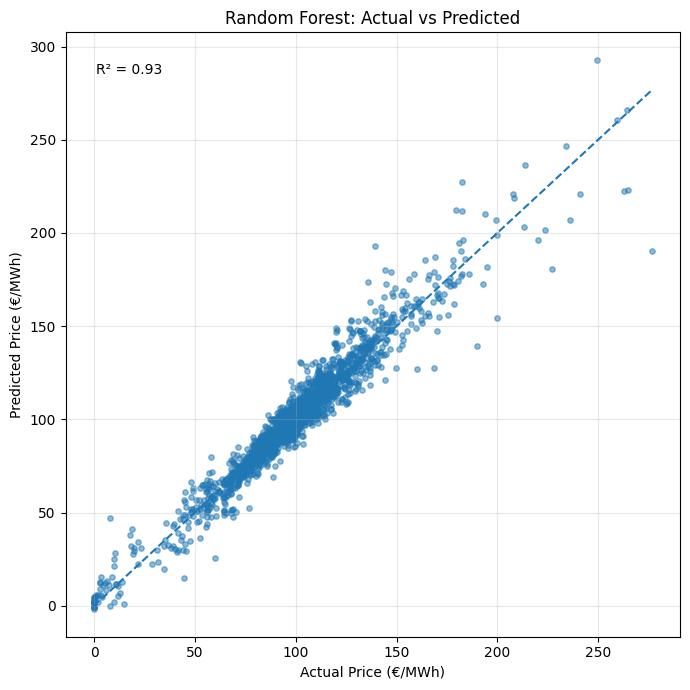

In [12]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, rf_predictions, alpha=0.5, s=15)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Actual Price (€/MWh)")
plt.ylabel("Predicted Price (€/MWh)")
plt.title("Random Forest: Actual vs Predicted")

plt.text(0.05, 0.95,
         f"R² = {r2_score(y_test, rf_predictions):.2f}",
         transform=plt.gca().transAxes,
         verticalalignment='top')

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("actual_vs_predicted.png", dpi=300)

plt.show()

Generating SHAP values...


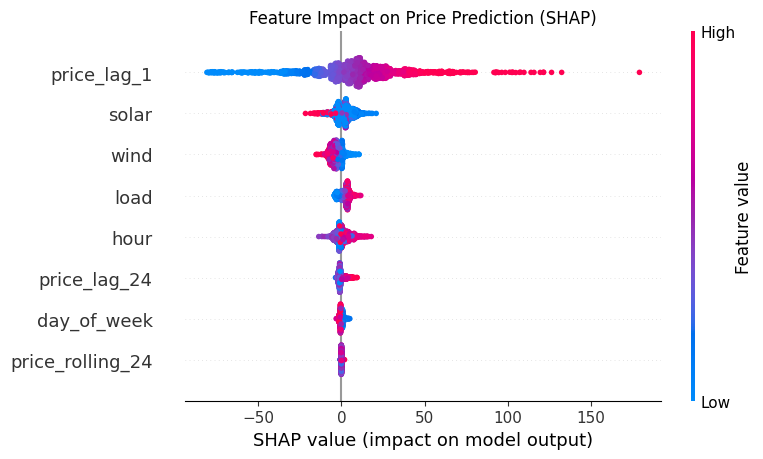

In [14]:
print("Generating SHAP values...")

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10,6))

shap.summary_plot(shap_values, X_test, show=False)

plt.title("Feature Impact on Price Prediction (SHAP)")
plt.tight_layout()

plt.savefig("shap_summary.png", dpi=300, bbox_inches='tight')
plt.show()

In [15]:
print("Key Insights:")
print("- Electricity prices increase with demand")
print("- Renewable energy reduces prices")
print("- Strong dependency on previous price (lag features)")

Key Insights:
- Electricity prices increase with demand
- Renewable energy reduces prices
- Strong dependency on previous price (lag features)
